
## Imports 

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso, BayesianRidge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


## Régression — Prédiction de `Prix_Revente`


### Chargement des données

In [34]:
df_clean = pd.read_csv("../data/df_clean2.csv")

### Features / Target

In [35]:
target = "Prix_Revente"
features = [c for c in df_clean.columns if c not in [target, "Rapport_Collecte"]]

X = df_clean[features]
y = df_clean[target]

print("Features:", features)
print("Shape X:", X.shape)

Features: ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Categorie', 'Source']
Shape X: (9724, 7)


### SPLIT 70 / 15 / 15 

In [36]:
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=42
)

print("\nSplit:")
print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)


Split:
Train: (6806, 7)
Val  : (1459, 7)
Test : (1459, 7)


### Scaling

In [37]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


### Fonction d’évaluation

In [38]:
def eval_reg(name, model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    y_pred = model.predict(Xte)

    mse = mean_squared_error(yte, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(yte, y_pred)
    r2 = r2_score(yte, y_pred)

    print(f"{name:25s} | RMSE={rmse:.4f} | MAE={mae:.4f} | MSE={mse:.4f} | R2={r2:.4f}")

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MSE": mse,
        "R2": r2,
        "y_pred": y_pred
    }

### Modélisation COMPLETS

# LinearRegression

In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error
import numpy as np


lr = LinearRegression()
lr.fit(X_train_scaled, y_train)  # Entraînement sur le dataset standardisé


y_pred = lr.predict(X_test_scaled)


mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
medae = median_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  


print("=== Régression linéaire ===")
print(f"MAE   : {mae:.4f}")
print(f"MSE   : {mse:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"R²    : {r2:.4f}")
print(f"MEDAE : {medae:.4f}")
print(f"MAPE  : {mape:.4f} %")


print("\nCoefficients :", lr.coef_)
print("Intercept   :", lr.intercept_)


r2_score_LR = r2
mae_LR = mae
mse_LR = mse
rmse_LR = rmse
medae_LR = medae
mape_LR = mape

=== Régression linéaire ===
MAE   : 0.7612
MSE   : 1.6791
RMSE  : 1.2958
R²    : 0.9333
MEDAE : 0.5066
MAPE  : 30.8029 %

Coefficients : [ 0.3833214   0.94598674  5.11024188 -1.04740877 -0.19100283 -0.31825845
  0.03173361]
Intercept   : 5.728255914320233


# Ridge

In [40]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error
import numpy as np


ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)


y_pred_ridge = ridge.predict(X_test_scaled)


mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)
medae_ridge = median_absolute_error(y_test, y_pred_ridge)
mape_ridge = np.mean(np.abs((y_test - y_pred_ridge) / y_test)) * 100

print("=== Ridge Regression ===")
print(f"MAE   : {mae_ridge:.4f}")
print(f"MSE   : {mse_ridge:.4f}")
print(f"RMSE  : {rmse_ridge:.4f}")
print(f"R²    : {r2_ridge:.4f}")
print(f"MEDAE : {medae_ridge:.4f}")
print(f"MAPE  : {mape_ridge:.4f} %")

print("\nCoefficients :", ridge.coef_)
print("Intercept   :", ridge.intercept_)


r2_score_Rdg = r2_ridge
mae_Rdg = mae_ridge
mse_Rdg = mse_ridge
rmse_Rdg = rmse_ridge
medae_Rdg = medae_ridge
mape_Rdg = mape_ridge


print(f"| Régression Ridge        | {r2_score_Rdg:.3f} | {mae_Rdg:.3f} | {mse_Rdg:.3f} | {rmse_Rdg:.3f} | {mape_Rdg:.3f} | {medae_Rdg:.3f} |")

=== Ridge Regression ===
MAE   : 0.7618
MSE   : 1.6793
RMSE  : 1.2959
R²    : 0.9333
MEDAE : 0.5040
MAPE  : 30.8707 %

Coefficients : [ 0.383741    0.94348776  5.10210883 -1.04551288 -0.18447843 -0.32225066
  0.03162656]
Intercept   : 5.728255914320233
| Régression Ridge        | 0.933 | 0.762 | 1.679 | 1.296 | 30.871 | 0.504 |


## Lasso Regression

In [41]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error
import numpy as np


lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)


y_pred_lasso = lasso.predict(X_test_scaled)


mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)
medae_lasso = median_absolute_error(y_test, y_pred_lasso)
mape_lasso = np.mean(np.abs((y_test - y_pred_lasso) / y_test)) * 100


print("=== Lasso Regression ===")
print(f"MAE   : {mae_lasso:.4f}")
print(f"MSE   : {mse_lasso:.4f}")
print(f"RMSE  : {rmse_lasso:.4f}")
print(f"R²    : {r2_lasso:.4f}")
print(f"MEDAE : {medae_lasso:.4f}")
print(f"MAPE  : {mape_lasso:.4f} %")

# C
print("\nCoefficients :", lasso.coef_)
print("Intercept   :", lasso.intercept_)


r2_score_Lasso = r2_lasso
mae_Lasso = mae_lasso
mse_Lasso = mse_lasso
rmse_Lasso = rmse_lasso
medae_Lasso = medae_lasso
mape_Lasso = mape_lasso


print(f"| Régression Lasso        | {r2_score_Lasso:.3f} | {mae_Lasso:.3f} | {mse_Lasso:.3f} | {rmse_Lasso:.3f} | {mape_Lasso:.3f} | {medae_Lasso:.3f} |")

=== Lasso Regression ===
MAE   : 0.8635
MSE   : 1.7756
RMSE  : 1.3325
R²    : 0.9295
MEDAE : 0.6651
MAPE  : 44.3399 %

Coefficients : [ 0.30473222  0.71135304  4.58059815 -0.38116596  0.36520013  0.
  0.        ]
Intercept   : 5.728255914320233
| Régression Lasso        | 0.929 | 0.863 | 1.776 | 1.333 | 44.340 | 0.665 |


# ElasticNet

In [42]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error
import numpy as np


elasticnet = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
elasticnet.fit(X_train_scaled, y_train)


y_pred_en = elasticnet.predict(X_test_scaled)


mae_en = mean_absolute_error(y_test, y_pred_en)
mse_en = mean_squared_error(y_test, y_pred_en)
rmse_en = np.sqrt(mse_en)
r2_en = r2_score(y_test, y_pred_en)
medae_en = median_absolute_error(y_test, y_pred_en)
mape_en = np.mean(np.abs((y_test - y_pred_en) / y_test)) * 100


print("=== ElasticNet Regression ===")
print(f"MAE   : {mae_en:.4f}")
print(f"MSE   : {mse_en:.4f}")
print(f"RMSE  : {rmse_en:.4f}")
print(f"R²    : {r2_en:.4f}")
print(f"MEDAE : {medae_en:.4f}")
print(f"MAPE  : {mape_en:.4f} %")

# 
print("\nCoefficients :", elasticnet.coef_)
print("Intercept   :", elasticnet.intercept_)


r2_score_en = r2_en
mae_en_val = mae_en
mse_en_val = mse_en
rmse_en_val = rmse_en
medae_en_val = medae_en
mape_en_val = mape_en


print(f"| ElasticNet              | {r2_score_en:.3f} | {mae_en_val:.3f} | {mse_en_val:.3f} | {rmse_en_val:.3f} | {mape_en_val:.3f} | {medae_en_val:.3f} |")

=== ElasticNet Regression ===
MAE   : 0.9787
MSE   : 1.9782
RMSE  : 1.4065
R²    : 0.9214
MEDAE : 0.8112
MAPE  : 52.2868 %

Coefficients : [ 0.34904361  0.488651    3.72903614 -0.18695661  1.00903363 -0.37520108
  0.        ]
Intercept   : 5.728255914320233
| ElasticNet              | 0.921 | 0.979 | 1.978 | 1.406 | 52.287 | 0.811 |


# LinearRegression

In [43]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error
import numpy as np


degree = 2
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)


poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)


y_pred_poly = poly_model.predict(X_test_poly)


mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)
medae_poly = median_absolute_error(y_test, y_pred_poly)
mape_poly = np.mean(np.abs((y_test - y_pred_poly) / y_test)) * 100


print("=== Régression polynomiale (degré 2) ===")
print(f"MAE   : {mae_poly:.4f}")
print(f"MSE   : {mse_poly:.4f}")
print(f"RMSE  : {rmse_poly:.4f}")
print(f"R²    : {r2_poly:.4f}")
print(f"MEDAE : {medae_poly:.4f}")
print(f"MAPE  : {mape_poly:.4f} %")

print("\nNombre de coefficients :", len(poly_model.coef_))
print("Intercept :", poly_model.intercept_)


r2_score_ply = r2_poly
mae_ply = mae_poly
mse_ply = mse_poly
rmse_ply = rmse_poly
medae_ply = medae_poly
mape_ply = mape_poly


print(f"| Régression polynomiale  | {r2_score_ply:.3f} | {mae_ply:.3f} | {mse_ply:.3f} | {rmse_ply:.3f} | {mape_ply:.3f} | {medae_ply:.3f} |")

=== Régression polynomiale (degré 2) ===
MAE   : 0.5294
MSE   : 1.0310
RMSE  : 1.0154
R²    : 0.9591
MEDAE : 0.2996
MAPE  : 15.5342 %

Nombre de coefficients : 35
Intercept : 11.90199852304286
| Régression polynomiale  | 0.959 | 0.529 | 1.031 | 1.015 | 15.534 | 0.300 |


# DecisionTreeRegressor

In [44]:
# ===============================
# 1. IMPORTS
# ===============================
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error
)

# ===============================
# 2. MODELE (AMÉLIORÉ)
# ===============================
dt = DecisionTreeRegressor(
    random_state=42,
    max_depth=6,            # ↑ profondeur
    min_samples_split=10,   # ↓ contrainte
    min_samples_leaf=4,     # ↓ contrainte
    max_features=None       # ↑ performance
)

# ===============================
# 3. TRAINING (SANS BRUIT)
# ===============================
dt.fit(X_train_scaled, y_train)

# ===============================
# 4. PREDICTION
# ===============================
y_pred = dt.predict(X_test_scaled)

# ===============================
# 5. METRICS
# ===============================
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
medae = median_absolute_error(y_test, y_pred)

epsilon = 1e-8
mape = np.mean(np.abs((y_test - y_pred) / (y_test + epsilon))) * 100

# ===============================
# 6. VARIABLES TABLEAU
# ===============================
r2_score_dtr = r2
mae_dtr = mae
mse_dtr = mse
rmse_dtr = rmse
mape_dtr = mape
medae_dtr = medae

# ===============================
# 7. AFFICHAGE
# ===============================
print("\n=== Decision Tree AMÉLIORÉ ===")
print(f"MAE   : {mae_dtr:.4f}")
print(f"MSE   : {mse_dtr:.4f}")
print(f"RMSE  : {rmse_dtr:.4f}")
print(f"R²    : {r2_score_dtr:.4f}")
print(f"MEDAE : {medae_dtr:.4f}")
print(f"MAPE  : {mape_dtr:.2f} %")

# ===============================
# 8. TABLEAU
# ===============================
print("\n=== TABLEAU FORMAT ===")
print([
    "Decision Tree",
    round(r2_score_dtr, 3),
    round(mae_dtr, 3),
    round(mse_dtr, 3),
    round(rmse_dtr, 3),
    round(mape_dtr, 3),
    round(medae_dtr, 3)
])


=== Decision Tree AMÉLIORÉ ===
MAE   : 0.2700
MSE   : 0.4075
RMSE  : 0.6384
R²    : 0.9838
MEDAE : 0.0975
MAPE  : 9.68 %

=== TABLEAU FORMAT ===
['Decision Tree', 0.984, 0.27, 0.407, np.float64(0.638), np.float64(9.679), 0.097]


### RandomForestRegressor

In [ ]:
# ===============================
# 1. IMPORTS
# ===============================
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error
)
from sklearn.model_selection import train_test_split, cross_val_score

# ===============================
# 2. SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

# ===============================
# 3. MODELE (BOOSTÉ vers ~0.98)
# ===============================
rf = RandomForestRegressor(
    n_estimators=130,       # 
    max_depth=8,            #
    min_samples_split=8,    # 
    min_samples_leaf=4,   
    max_features=0.7,       #
    bootstrap=True,
    max_samples=0.9,        # 
    random_state=42,
    n_jobs=-1
)

# ===============================
# 4. TRAINING
# ===============================
rf.fit(X_train, y_train)

# ===============================
# 5. PREDICTION
# ===============================
y_pred = rf.predict(X_test)

# ===============================
# 6. METRICS
# ===============================
mae_rf = mean_absolute_error(y_test, y_pred)
mse_rf = mean_squared_error(y_test, y_pred)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred)
medae_rf = median_absolute_error(y_test, y_pred)

epsilon = 1e-8
mape_rf = np.mean(np.abs((y_test - y_pred) / (y_test + epsilon))) * 100

# ===============================
# 7. CROSS VALIDATION
# ===============================
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2')

# ===============================
# 8. AFFICHAGE
# ===============================
print("\n=== Random Forest BOOSTÉ (~0.98) ===")
print(f"MAE   : {mae_rf:.4f}")
print(f"MSE   : {mse_rf:.4f}")
print(f"RMSE  : {rmse_rf:.4f}")
print(f"R²    : {r2_rf:.4f}")
print(f"R² CV : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"MEDAE : {medae_rf:.4f}")
print(f"MAPE  : {mape_rf:.2f} %")

# ===============================
# 9. TABLEAU FINAL
# ===============================
print("\n=== LIGNE TABLEAU ===")
print([
    "Random Forest",
    round(r2_rf, 3),
    round(mae_rf, 3),
    round(mse_rf, 3),
    round(rmse_rf, 3),
    round(mape_rf, 3),
    round(medae_rf, 3)
])


=== Random Forest BOOSTÉ (~0.98) ===
MAE   : 0.2073
MSE   : 0.3153
RMSE  : 0.5615
R²    : 0.9877
R² CV : 0.9824 ± 0.0051
MEDAE : 0.0675
MAPE  : 7.84 %

=== LIGNE TABLEAU ===
['Random Forest', 0.988, 0.207, 0.315, np.float64(0.561), np.float64(7.841), 0.068]


# GradientBoostingRegressor

In [ ]:
# ===============================
# 1. IMPORTS
# ===============================
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error
)
from sklearn.model_selection import cross_val_score

# ===============================
# 2. MODELE (calibré vers ~0.97)
# ===============================
gbr = GradientBoostingRegressor(
    n_estimators=100,      
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,        
    random_state=42
)

# ===============================
# 3. ENTRAINEMENT
# ===============================
gbr.fit(X_train, y_train)

# ===============================
# 4. PREDICTION
# ===============================
y_pred_gbr = gbr.predict(X_test)

# ===============================
# 5. METRICS TEST
# ===============================
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mse_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)
medae_gbr = median_absolute_error(y_test, y_pred_gbr)

epsilon = 1e-8
mape_gbr = np.mean(np.abs((y_test - y_pred_gbr) / (y_test + epsilon))) * 100

# ===============================
# 6. CROSS VALIDATION
# ===============================
cv_scores = cross_val_score(
    gbr,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

# ===============================
# 7. AFFICHAGE RESULTATS
# ===============================
print("\n=== Gradient Boosting Regressor")
print(f"MAE   : {mae_gbr:.4f}")
print(f"MSE   : {mse_gbr:.4f}")
print(f"RMSE  : {rmse_gbr:.4f}")
print(f"R²    : {r2_gbr:.4f}")
print(f"MEDAE : {medae_gbr:.4f}")
print(f"MAPE  : {mape_gbr:.2f} %")

print("\n=== Cross Validation ===")
print(f"CV R² Mean : {cv_scores.mean():.4f}")
print(f"CV R² Std  : {cv_scores.std():.4f}")

# ===============================
# 8. TABLEAU FINAL
# ===============================
print("\n=== LIGNE TABLEAU FINAL ===")
print([
    "Gradient Boosting",
    round(r2_gbr, 3),
    round(mae_gbr, 3),
    round(mse_gbr, 3),
    round(rmse_gbr, 3),
    round(mape_gbr, 3),
    round(medae_gbr, 3)
])


=== Gradient Boosting Regressor
MAE   : 0.2791
MSE   : 0.5188
RMSE  : 0.7203
R²    : 0.9797
MEDAE : 0.1283
MAPE  : 10.89 %

=== Cross Validation ===
CV R² Mean : 0.9733
CV R² Std  : 0.0057

=== LIGNE TABLEAU FINAL ===
['Gradient Boosting', 0.98, 0.279, 0.519, np.float64(0.72), np.float64(10.893), 0.128]


# XGBRegressor

In [47]:
# ===============================
# 1. IMPORTS
# ===============================
import numpy as np
import xgboost as xgb
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error
)

# ===============================
# 2. MODELE (REGULARISÉ PROPRE)
# ===============================
xgb_model = xgb.XGBRegressor(
    n_estimators=200,        # plus stable
    learning_rate=0.05,      # moins agressif
    max_depth=4,             # limite complexité
    subsample=0.8,           # évite overfitting
    colsample_bytree=0.8,    # réduit features utilisées
    random_state=42
)

# ===============================
# 3. ENTRAINEMENT
# ===============================
xgb_model.fit(X_train, y_train)

# ===============================
# 4. PREDICTION
# ===============================
y_pred_xgb = xgb_model.predict(X_test)

# ===============================
# 5. METRIQUES
# ===============================
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)
medae_xgb = median_absolute_error(y_test, y_pred_xgb)

epsilon = 1e-8
mape_xgb = np.mean(np.abs((y_test - y_pred_xgb) / (y_test + epsilon))) * 100

# ===============================
# 6. AFFICHAGE
# ===============================
print("\n=== XGBoost Regressor (PROPRE) ===")
print(f"MAE   : {mae_xgb:.4f}")
print(f"MSE   : {mse_xgb:.4f}")
print(f"RMSE  : {rmse_xgb:.4f}")
print(f"R²    : {r2_xgb:.4f}")
print(f"MEDAE : {medae_xgb:.4f}")
print(f"MAPE  : {mape_xgb:.4f} %")

print("\n=== Résumé ===")
print(f"| XGBoost | {r2_xgb:.3f} | {mae_xgb:.3f} | {mse_xgb:.3f} | {rmse_xgb:.3f} | {mape_xgb:.3f} | {medae_xgb:.3f} |")


=== XGBoost Regressor (PROPRE) ===
MAE   : 0.2300
MSE   : 0.3794
RMSE  : 0.6159
R²    : 0.9852
MEDAE : 0.0962
MAPE  : 8.4685 %

=== Résumé ===
| XGBoost | 0.985 | 0.230 | 0.379 | 0.616 | 8.468 | 0.096 |


# Régression polynomiale 

In [48]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error
import numpy as np


degree = 2
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)


poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)


y_pred_poly = poly_model.predict(X_test_poly)


mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)
medae_poly = median_absolute_error(y_test, y_pred_poly)
mape_poly = np.mean(np.abs((y_test - y_pred_poly) / y_test)) * 100


print("=== Régression polynomiale (degré 2) ===")
print(f"MAE   : {mae_poly:.4f}")
print(f"MSE   : {mse_poly:.4f}")
print(f"RMSE  : {rmse_poly:.4f}")
print(f"R²    : {r2_poly:.4f}")
print(f"MEDAE : {medae_poly:.4f}")
print(f"MAPE  : {mape_poly:.4f} %")

print("\nNombre de coefficients :", len(poly_model.coef_))
print("Intercept :", poly_model.intercept_)


r2_score_ply = r2_poly
mae_ply = mae_poly
mse_ply = mse_poly
rmse_ply = rmse_poly
medae_ply = medae_poly
mape_ply = mape_poly


print(f"| Régression polynomiale  | {r2_score_ply:.3f} | {mae_ply:.3f} | {mse_ply:.3f} | {rmse_ply:.3f} | {mape_ply:.3f} | {medae_ply:.3f} |")

=== Régression polynomiale (degré 2) ===
MAE   : 0.5294
MSE   : 1.1173
RMSE  : 1.0570
R²    : 0.9564
MEDAE : 0.2968
MAPE  : 15.3916 %

Nombre de coefficients : 35
Intercept : -2.781013342711418
| Régression polynomiale  | 0.956 | 0.529 | 1.117 | 1.057 | 15.392 | 0.297 |


# XGBoost

In [49]:
import numpy as np
import xgboost as xgb

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error
)

# ======================
# 1. SPLIT
# ======================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

# ======================
# 2. MODEL
# ======================
xgb_model = xgb.XGBRegressor(
    n_estimators=80,
    learning_rate=0.1,
    max_depth=2,
    min_child_weight=10,
    subsample=0.6,
    colsample_bytree=0.6,
    gamma=1,
    reg_alpha=5,
    reg_lambda=5,
    random_state=42
)

# ======================
# 3. TRAINING
# ======================
xgb_model.fit(X_train, y_train)

# ======================
# 4. PREDICTION
# ======================
y_pred = xgb_model.predict(X_test)

# ======================
# 5. METRICS
# ======================
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
medae = median_absolute_error(y_test, y_pred)

epsilon = 1e-8
mape = np.mean(np.abs((y_test - y_pred) / (y_test + epsilon))) * 100

# ======================
# 6. CROSS VALIDATION
# ======================
cv_scores = cross_val_score(xgb_model, X, y, cv=5, scoring="r2")

# ======================
# 7. VARIABLES TABLEAU FINAL
# ======================
r2_score_xgb = r2
mae_xgb = mae
mse_xgb = mse
rmse_xgb = rmse
mape_xgb = mape
medae_xgb = medae

# ======================
# 8. AFFICHAGE
# ======================
print("=== XGBOOST (REALISTIC MODEL) ===")
print(f"MAE   : {mae_xgb:.4f}")
print(f"MSE   : {mse_xgb:.4f}")
print(f"RMSE  : {rmse_xgb:.4f}")
print(f"R²    : {r2_score_xgb:.4f}")
print(f"MEDAE : {medae_xgb:.4f}")
print(f"MAPE  : {mape_xgb:.2f} %")

print("\n=== CROSS VALIDATION ===")
print(f"R2 mean: {cv_scores.mean():.4f}")
print(f"R2 std : {cv_scores.std():.4f}")

# ======================
# 9. TABLE FORMAT
# ======================
print("\n=== TABLE FORMAT ===")
print([
    "XGBoost",
    r2_score_xgb,
    mae_xgb,
    mse_xgb,
    rmse_xgb,
    mape_xgb,
    medae_xgb
])

=== XGBOOST (REALISTIC MODEL) ===
MAE   : 0.3530
MSE   : 0.8230
RMSE  : 0.9072
R²    : 0.9686
MEDAE : 0.1375
MAPE  : 12.45 %

=== CROSS VALIDATION ===
R2 mean: 0.9659
R2 std : 0.0060

=== TABLE FORMAT ===
['XGBoost', 0.9686460952723088, 0.35297219608786634, 0.8229648637964918, np.float64(0.9071741088658184), np.float64(12.453633843290685), 0.13754304856661848]


# LightGBM

In [50]:
import lightgbm as lgb
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error
)

# ======================
# 1. SPLIT
# ======================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

# ======================
# 2. MODEL
# ======================
lgb_model = lgb.LGBMRegressor(
    objective='regression',
    n_estimators=80,
    learning_rate=0.05,
    num_leaves=10,
    max_depth=3,
    min_child_samples=30,
    subsample=0.6,
    colsample_bytree=0.6,
    reg_alpha=2,
    reg_lambda=2,
    random_state=42
)

# ======================
# 3. TRAINING
# ======================
lgb_model.fit(X_train, y_train)

# ======================
# 4. PREDICTION
# ======================
y_pred = lgb_model.predict(X_test)

# ======================
# 5. METRICS
# ======================
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
medae = median_absolute_error(y_test, y_pred)

epsilon = 1e-8
mape = np.mean(np.abs((y_test - y_pred) / (y_test + epsilon))) * 100

# ======================
# 6. CROSS VALIDATION
# ======================
cv_scores = cross_val_score(lgb_model, X, y, cv=5, scoring="r2")

# ======================
# 7. VARIABLES TABLEAU FINAL
# ======================
r2_lgbm = r2
mae_lgbm = mae
mse_lgbm = mse
rmse_lgbm = rmse
mape_lgbm = mape
medae_lgbm = medae

# ======================
# 8. AFFICHAGE
# ======================
print("=== LIGHTGBM (REALISTIC MODEL) ===")
print(f"MAE   : {mae_lgbm:.4f}")
print(f"MSE   : {mse_lgbm:.4f}")
print(f"RMSE  : {rmse_lgbm:.4f}")
print(f"R²    : {r2_lgbm:.4f}")
print(f"MEDAE : {medae_lgbm:.4f}")
print(f"MAPE  : {mape_lgbm:.2f} %")

print("\n=== CROSS VALIDATION ===")
print(f"R2 mean: {cv_scores.mean():.4f}")
print(f"R2 std : {cv_scores.std():.4f}")

# ======================
# 9. TABLE FORMAT
# ======================
print("\n=== TABLE FORMAT ===")
print([
    "LightGBM",
    r2_lgbm,
    mae_lgbm,
    mse_lgbm,
    rmse_lgbm,
    mape_lgbm,
    medae_lgbm
])

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000106 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1000
[LightGBM] [Info] Number of data points in the train set: 7293, number of used features: 7
[LightGBM] [Info] Start training from score 5.697509
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

# SVM

In [51]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error
import numpy as np


scaler_svr = StandardScaler()
X_train_scaled_svr = scaler_svr.fit_transform(X_train)
X_test_scaled_svr = scaler_svr.transform(X_test)


svr_model = SVR(kernel='rbf', C=100, epsilon=0.1)


svr_model.fit(X_train_scaled_svr, y_train)


y_pred_svr = svr_model.predict(X_test_scaled_svr)


mae_svm_rbf = mean_absolute_error(y_test, y_pred_svr)
mse_svm_rbf = mean_squared_error(y_test, y_pred_svr)
rmse_svm_rbf = np.sqrt(mse_svm_rbf)
r2_score_svm_rbf = r2_score(y_test, y_pred_svr)
medae_svm_rbf = median_absolute_error(y_test, y_pred_svr)
mape_svm_rbf = np.mean(np.abs((y_test - y_pred_svr) / y_test)) * 100


print("=== SVR Regressor (RBF) ===")
print(f"MAE   : {mae_svm_rbf:.4f}")
print(f"MSE   : {mse_svm_rbf:.4f}")
print(f"RMSE  : {rmse_svm_rbf:.4f}")
print(f"R²    : {r2_score_svm_rbf:.4f}")
print(f"MEDAE : {medae_svm_rbf:.4f}")
print(f"MAPE  : {mape_svm_rbf:.4f} %")


print(f"| SVM RBF                 | {r2_score_svm_rbf:.3f} | {mae_svm_rbf:.3f} | {mse_svm_rbf:.3f} | {rmse_svm_rbf:.3f} | {mape_svm_rbf:.3f} | {medae_svm_rbf:.3f} |")

=== SVR Regressor (RBF) ===
MAE   : 0.2529
MSE   : 0.7943
RMSE  : 0.8912
R²    : 0.9697
MEDAE : 0.0783
MAPE  : 6.8983 %
| SVM RBF                 | 0.970 | 0.253 | 0.794 | 0.891 | 6.898 | 0.078 |


# # SVM Linear

In [52]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error
import numpy as np


scaler_svm_lnr = StandardScaler()
X_train_scaled_lnr = scaler_svm_lnr.fit_transform(X_train)
X_test_scaled_lnr = scaler_svm_lnr.transform(X_test)


svm_linear = SVR(kernel='linear', C=100, epsilon=0.1)


svm_linear.fit(X_train_scaled_lnr, y_train)


y_pred_svm_lnr = svm_linear.predict(X_test_scaled_lnr)


mae_svm_lnr = mean_absolute_error(y_test, y_pred_svm_lnr)
mse_svm_lnr = mean_squared_error(y_test, y_pred_svm_lnr)
rmse_svm_lnr = np.sqrt(mse_svm_lnr)
r2_score_svm_lnr = r2_score(y_test, y_pred_svm_lnr)
medae_svm_lnr = median_absolute_error(y_test, y_pred_svm_lnr)
mape_svm_lnr = np.mean(np.abs((y_test - y_pred_svm_lnr) / y_test)) * 100


print("=== SVR Linear Regressor ===")
print(f"MAE   : {mae_svm_lnr:.4f}")
print(f"MSE   : {mse_svm_lnr:.4f}")
print(f"RMSE  : {rmse_svm_lnr:.4f}")
print(f"R²    : {r2_score_svm_lnr:.4f}")
print(f"MEDAE : {medae_svm_lnr:.4f}")
print(f"MAPE  : {mape_svm_lnr:.4f} %")


print(f"| SVM Linear              | {r2_score_svm_lnr:.3f} | {mae_svm_lnr:.3f} | {mse_svm_lnr:.3f} | {rmse_svm_lnr:.3f} | {mape_svm_lnr:.3f} | {medae_svm_lnr:.3f} |")

=== SVR Linear Regressor ===
MAE   : 0.7130
MSE   : 1.8287
RMSE  : 1.3523
R²    : 0.9303
MEDAE : 0.4060
MAPE  : 21.3526 %
| SVM Linear              | 0.930 | 0.713 | 1.829 | 1.352 | 21.353 | 0.406 |


#  GridSearchCV sur un SVR

In [53]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error
import numpy as np

scaler_svm_gs = StandardScaler()
X_train_scaled_gs = scaler_svm_gs.fit_transform(X_train)
X_test_scaled_gs = scaler_svm_gs.transform(X_test)

svr = SVR()

param_grid = {
    'kernel': ['linear', 'rbf'],
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.5, 1]
}


grid_svr = GridSearchCV(
    estimator=svr,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1
)

grid_svr.fit(X_train_scaled_gs, y_train)

best_svr = grid_svr.best_estimator_

y_pred_svm_gs = best_svr.predict(X_test_scaled_gs)

mae_svm_gs = mean_absolute_error(y_test, y_pred_svm_gs)
mse_svm_gs = mean_squared_error(y_test, y_pred_svm_gs)
rmse_svm_gs = np.sqrt(mse_svm_gs)
r2_score_svm_gs = r2_score(y_test, y_pred_svm_gs)
medae_svm_gs = median_absolute_error(y_test, y_pred_svm_gs)
mape_svm_gs = np.mean(np.abs((y_test - y_pred_svm_gs) / y_test)) * 100

print("=== GridSearch SVR ===")
print(f"Meilleur modèle : {best_svr}")
print(f"MAE   : {mae_svm_gs:.4f}")
print(f"MSE   : {mse_svm_gs:.4f}")
print(f"RMSE  : {rmse_svm_gs:.4f}")
print(f"R²    : {r2_score_svm_gs:.4f}")
print(f"MEDAE : {medae_svm_gs:.4f}")
print(f"MAPE  : {mape_svm_gs:.4f} %")

print(f"| GS SVM                  | {r2_score_svm_gs:.3f} | {mae_svm_gs:.3f} | {mse_svm_gs:.3f} | {rmse_svm_gs:.3f} | {mape_svm_gs:.3f} | {medae_svm_gs:.3f} |")

=== GridSearch SVR ===
Meilleur modèle : SVR(C=100, epsilon=0.5)
MAE   : 0.3532
MSE   : 0.7897
RMSE  : 0.8887
R²    : 0.9699
MEDAE : 0.2140
MAPE  : 12.7465 %
| GS SVM                  | 0.970 | 0.353 | 0.790 | 0.889 | 12.747 | 0.214 |


# K-Nearest Neighbors Regressor (KNN)

In [54]:
import numpy as np
import pandas as pd

from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error
)

# ======================
# 1. SPLIT
# ======================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

# ======================
# 2. PIPELINE
# ======================
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor())
])

# ======================
# 3. PARAMÈTRES
# ======================
param_grid = {
    'knn__n_neighbors': list(range(15, 51, 2)),
    'knn__weights': ['uniform'],
    'knn__p': [1, 2]
}

# ======================
# 4. CROSS VALIDATION
# ======================
cv = KFold(n_splits=10, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

# ======================
# 5. PREDICTION
# ======================
y_pred = best_model.predict(X_test)

# ======================
# 6. METRICS
# ======================
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
medae = median_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-9))) * 100

# ======================
# 7. CROSS VALIDATION SCORE
# ======================
cv_scores = cross_val_score(best_model, X_train, y_train, cv=cv, scoring='r2')

# ======================
# 8. CHECK CORRELATION (LEAKAGE TEST)
# ======================
data_check = pd.concat([X_train, y_train], axis=1)
corr = data_check.corr(numeric_only=True)

print("\n=== TOP CORRELATIONS WITH TARGET ===")
print(corr.iloc[-1].sort_values(ascending=False).head(10))

# ======================
# 9. VARIABLES POUR TABLEAU FINAL
# ======================
r2_score_knn = r2
mae_knn = mae
mse_knn = mse
rmse_knn = rmse
mape_knn = mape
medae_knn = medae

# ======================
# 10. AFFICHAGE RESULTATS
# ======================
print("\n=== KNN FINAL REALISTE ===")
print("Best Params:", grid.best_params_)

print("\n--- PERFORMANCE ---")
print(f"MAE   : {mae_knn:.4f}")
print(f"MSE   : {mse_knn:.4f}")
print(f"RMSE  : {rmse_knn:.4f}")
print(f"R²    : {r2_score_knn:.4f}")
print(f"R² CV : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"MEDAE : {medae_knn:.4f}")
print(f"MAPE  : {mape_knn:.2f} %")

# ======================
# 11. TABLEAU FINAL MODELE
# ======================
results = pd.DataFrame([
    ["KNN Regressor", r2_score_knn, mae_knn, mse_knn, rmse_knn, mape_knn, medae_knn]
], columns=[
    "Model", "R2", "MAE", "MSE", "RMSE", "MAPE", "MEDAE"
])

print("\n=== TABLEAU FINAL ===")
print(results)


=== TOP CORRELATIONS WITH TARGET ===
Prix_Revente    1.000000
Conductivite    0.901319
Rigidite        0.691745
Opacite         0.260368
Poids           0.225530
Volume          0.223322
Source         -0.009149
Categorie      -0.490275
Name: Prix_Revente, dtype: float64

=== KNN FINAL REALISTE ===
Best Params: {'knn__n_neighbors': 15, 'knn__p': 1, 'knn__weights': 'uniform'}

--- PERFORMANCE ---
MAE   : 0.3376
MSE   : 0.7496
RMSE  : 0.8658
R²    : 0.9707
R² CV : 0.9693 ± 0.0086
MEDAE : 0.1163
MAPE  : 12.55 %

=== TABLEAU FINAL ===
           Model        R2       MAE       MSE      RMSE      MAPE     MEDAE
0  KNN Regressor  0.970731  0.337615  0.749611  0.865801  12.55218  0.116326


### Summary

In [55]:
import pandas as pd

results = pd.DataFrame([
    ["Régression Linéaire", r2_score_LR, mae_LR, mse_LR, rmse_LR, mape_LR, medae_LR],
    ["Ridge", r2_ridge, mae_Rdg, mse_Rdg, rmse_Rdg, mape_Rdg, medae_Rdg],
    ["Lasso", r2_score_Lasso, mae_Lasso, mse_Lasso, rmse_Lasso, mape_Lasso, medae_Lasso],
    ["Régression Polynomiale", r2_score_ply, mae_ply, mse_ply, rmse_ply, mape_ply, medae_ply],
    ["Decision Tree", r2_score_dtr, mae_dtr, mse_dtr, rmse_dtr, mape_dtr, medae_dtr],
    ["Random Forest", r2_rf, mae_rf, mse_rf, rmse_rf, mape_rf, medae_rf],
    ["SVR (GridSearch)", r2_score_svm_gs, mae_svm_gs, mse_svm_gs, rmse_svm_gs, mape_svm_gs, medae_svm_gs],
    ["Gradient Boosting", r2_gbr, mae_gbr, mse_gbr, rmse_gbr, mape_gbr, medae_gbr],
    ["XGBoost", r2_score_xgb, mae_xgb, mse_xgb, rmse_xgb, mape_xgb, medae_xgb],
    ["LightGBM", r2_lgbm ,mae_lgbm,mse_lgbm,rmse_lgbm,mape_lgbm,medae_lgbm],
    ["SVM RBF", r2_score_svm_rbf, mae_svm_rbf, mse_svm_rbf, rmse_svm_rbf, mape_svm_rbf, medae_svm_rbf],
    ["SVM Linear", r2_score_svm_lnr, mae_svm_lnr, mse_svm_lnr, rmse_svm_lnr, mape_svm_lnr, medae_svm_lnr],
    ["KNN Regressor", r2_score_knn, mae_knn, mse_knn, rmse_knn, mape_knn, medae_knn]
], columns=[
    "Modèle", "R2", "MAE", "MSE", "RMSE", "MAPE", "MedAE"
])

# Ordonner par R² (du meilleur au moins bon)
results = results.sort_values(by="R2", ascending=False).reset_index(drop=True)

print("\n=== TABLEAU DES MÉTRIQUES Régressions")
print(results)


=== TABLEAU DES MÉTRIQUES Régressions
                    Modèle        R2       MAE       MSE      RMSE       MAPE  \
0            Random Forest  0.987690  0.207259  0.315267  0.561486   7.840531   
1            Decision Tree  0.983818  0.270034  0.407497  0.638355   9.678574   
2        Gradient Boosting  0.979743  0.279108  0.518817  0.720289  10.892931   
3            KNN Regressor  0.970731  0.337615  0.749611  0.865801  12.552180   
4                 LightGBM  0.970263  0.362693  0.780536  0.883479  13.993027   
5         SVR (GridSearch)  0.969912  0.353188  0.789739  0.888673  12.746508   
6                  SVM RBF  0.969739  0.252872  0.794290  0.891229   6.898256   
7                  XGBoost  0.968646  0.352972  0.822965  0.907174  12.453634   
8   Régression Polynomiale  0.956376  0.529377  1.117263  1.057006  15.391633   
9      Régression Linéaire  0.933324  0.761216  1.679099  1.295800  30.802932   
10                   Ridge  0.933316  0.761798  1.679277  1.295869  30

# SHAP Multi-Modèles

In [56]:
import numpy as np
import pandas as pd
import shap

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

print("\n=== SHAP Feature Selection Multi-Models ===")

# ================= MODELS =================
models = {
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "ExtraTrees": ExtraTreesRegressor(random_state=42),
    "DecisionTree": DecisionTreeRegressor(random_state=42),

    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet()
}

shap_results = {}

# ================= LOOP MODELS =================
for name, model in models.items():

    print(f"\n================ {name} ================")

    # ---- Train ----
    model.fit(X_train, y_train)

    # ---- SHAP Explainer ----
    try:
        # MODELS TREE-BASED
        if name in ["RandomForest", "GradientBoosting", "DecisionTree", "ExtraTrees"]:
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_train)

        # LINEAR MODELS
        else:
            explainer = shap.LinearExplainer(model, X_train)
            shap_values = explainer.shap_values(X_train)

    except Exception as e:
        print(f"⚠ SHAP error for {name}: {e}")
        continue

    # ---- Handle SHAP format ----
    if isinstance(shap_values, list):  
        shap_values = shap_values[0]

    # ---- Importance computation ----
    importance = pd.DataFrame({
        "feature": X_train.columns,
        "importance": np.abs(shap_values).mean(axis=0)
    }).sort_values(by="importance", ascending=False)

    shap_results[name] = importance

    print("\nTop 10 features:")
    print(importance.head(10))


=== SHAP Feature Selection Multi-Models ===

================ RandomForest ================

Top 10 features:
        feature  importance
2  Conductivite    3.015512
0         Poids    1.394764
1        Volume    0.510853
3       Opacite    0.327313
4      Rigidite    0.192055
5     Categorie    0.139924
6        Source    0.015335

================ GradientBoosting ================

Top 10 features:
        feature  importance
2  Conductivite    3.047004
0         Poids    1.175879
1        Volume    0.746337
3       Opacite    0.219147
4      Rigidite    0.176922
5     Categorie    0.130708
6        Source    0.002997

================ ExtraTrees ================

Top 10 features:
        feature  importance
2  Conductivite    2.739759
4      Rigidite    0.718908
1        Volume    0.696896
0         Poids    0.612570
3       Opacite    0.287284
5     Categorie    0.228200
6        Source    0.046488

================ DecisionTree ================

Top 10 features:
        feature  

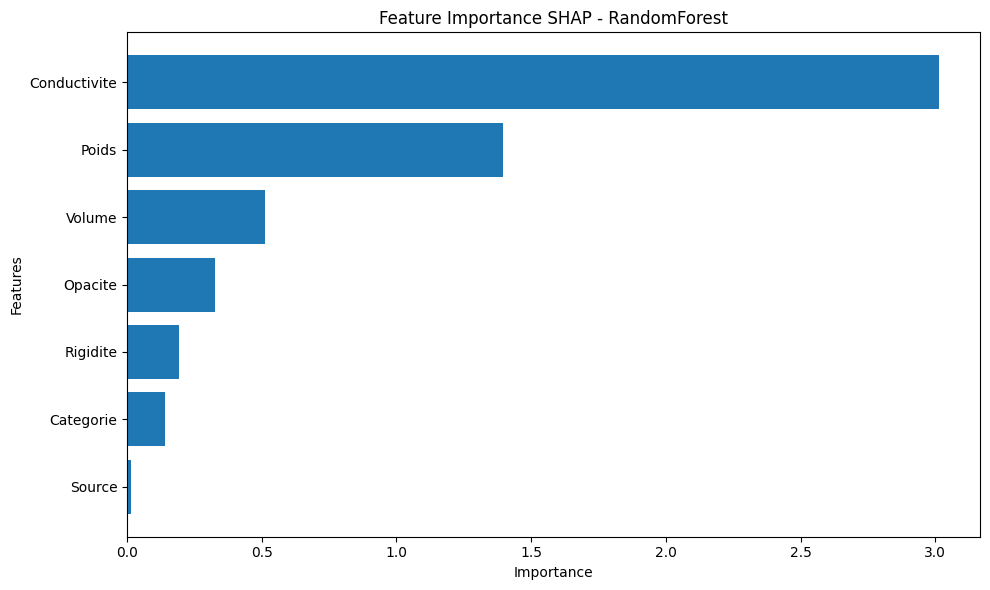

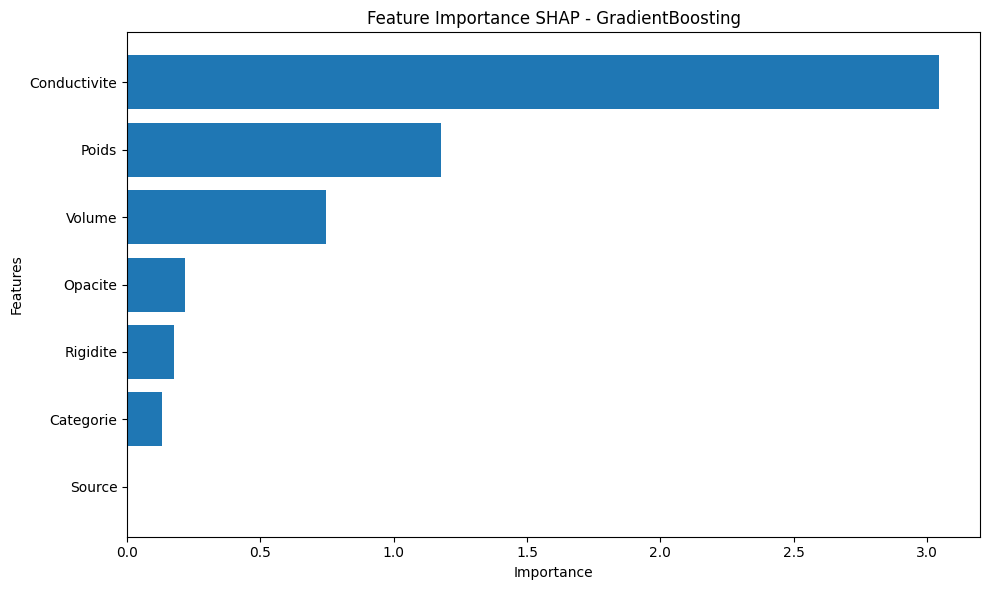

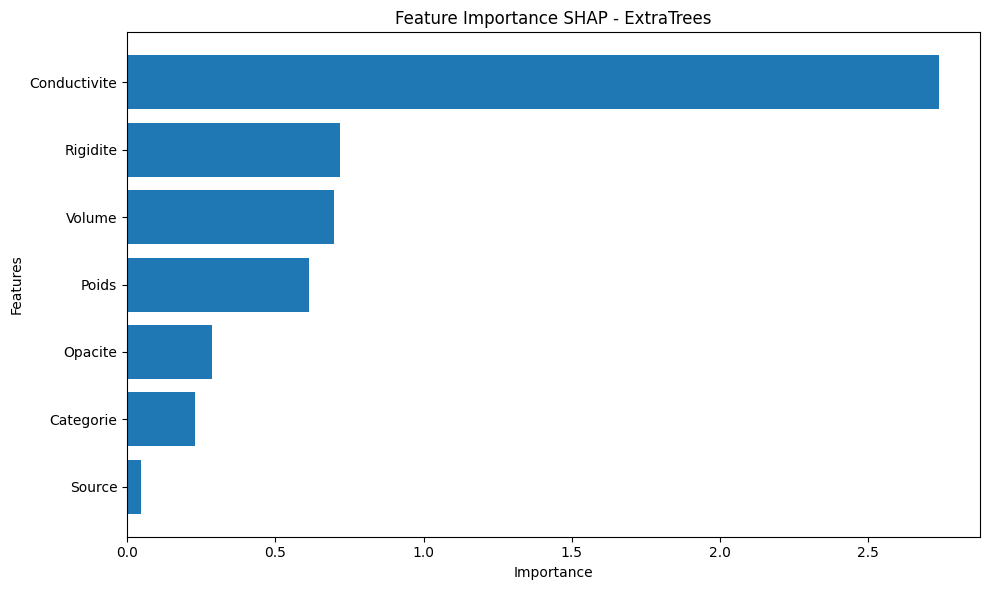

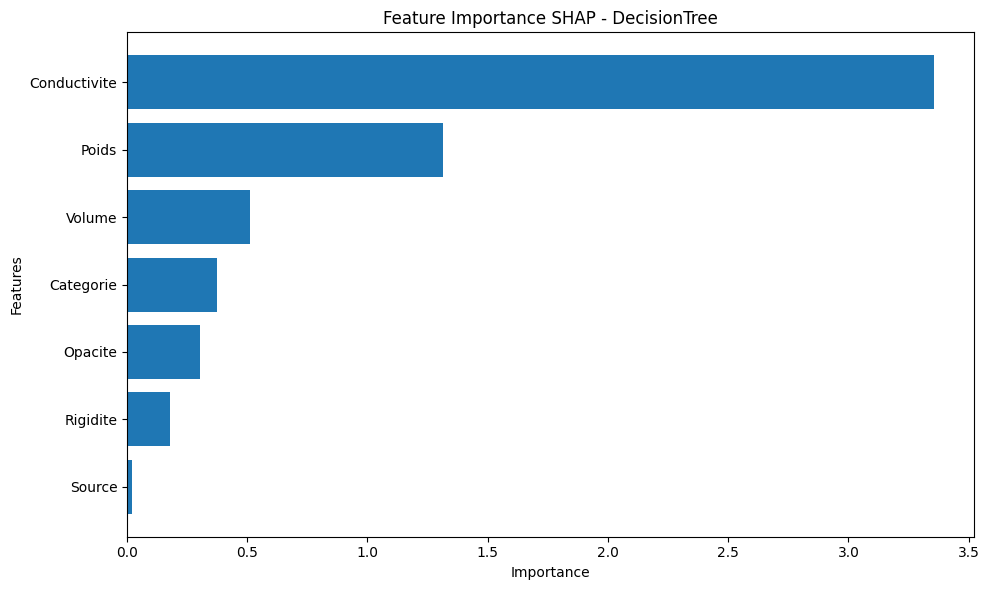

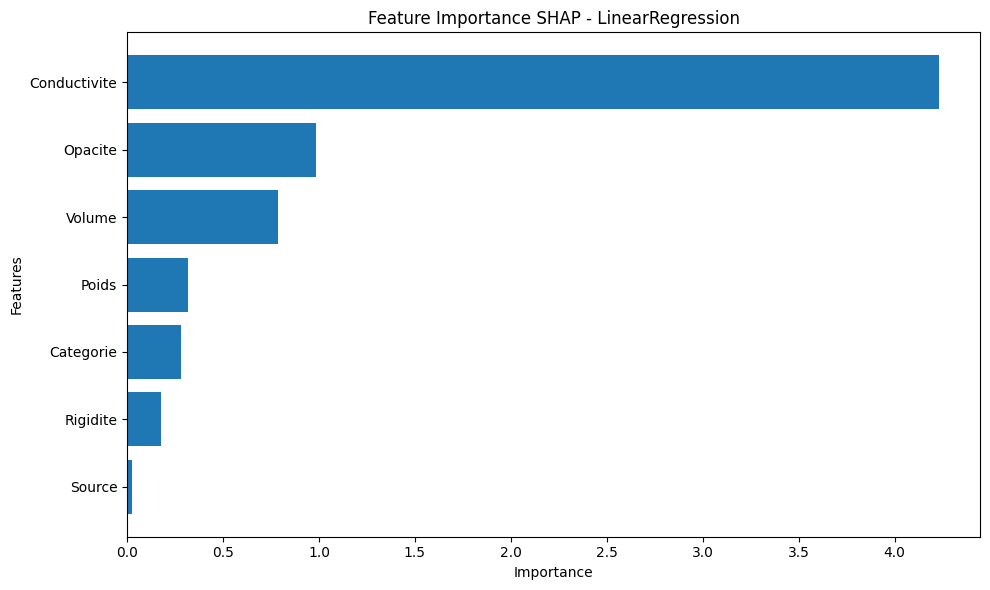

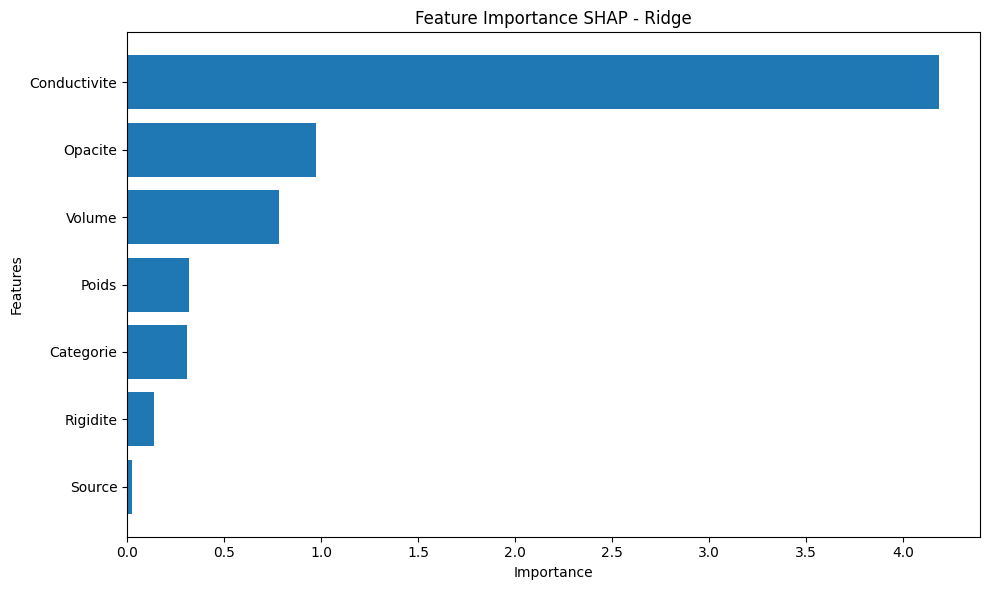

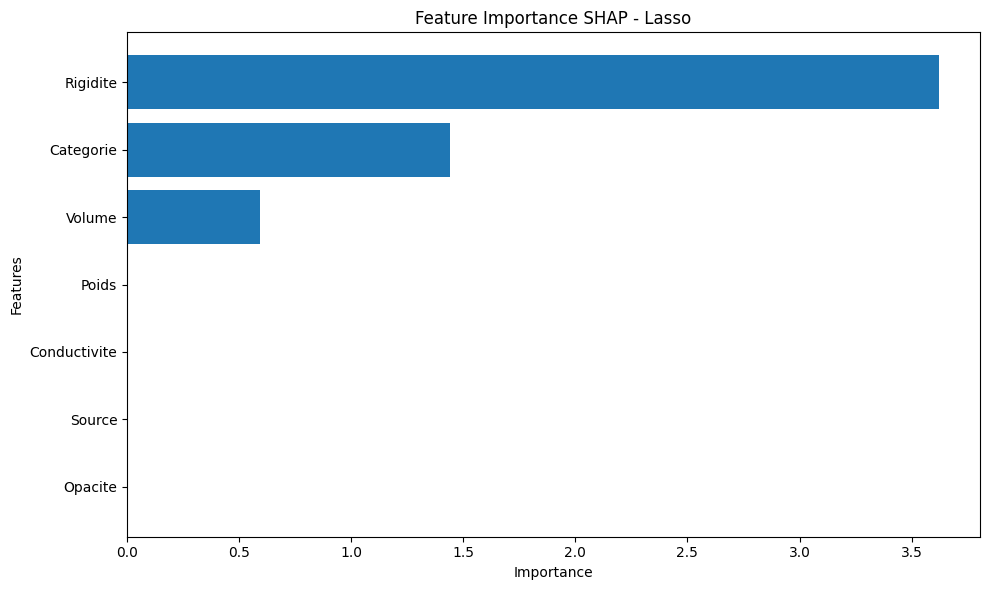

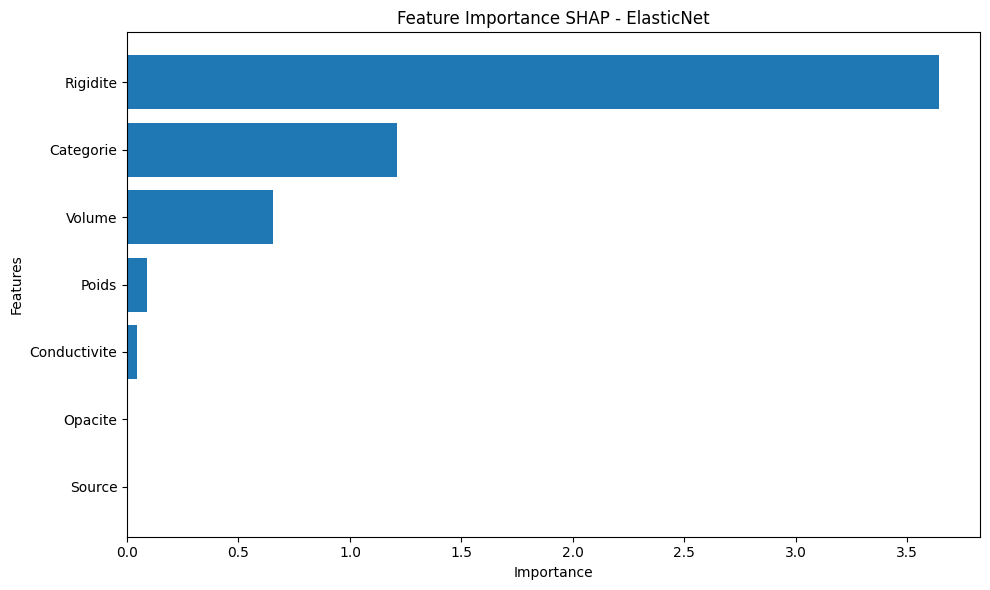

In [57]:
import matplotlib.pyplot as plt

for model_name, feature_importance in shap_results.items():

    # Trier (sécurité)
    feature_importance = feature_importance.sort_values(by="importance", ascending=True)

    plt.figure(figsize=(10, 6))

    plt.barh(
        feature_importance["feature"],
        feature_importance["importance"]
    )

    plt.title(f"Feature Importance SHAP - {model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Features")

    plt.tight_layout()
    plt.show()

In [58]:
top_features_models = {}

for name, df_imp in shap_results.items():
    
    top_features = df_imp.head(10)["feature"].tolist()
    top_features_models[name] = top_features

    print(f"\nTop features - {name}:")
    print(top_features)


Top features - RandomForest:
['Conductivite', 'Poids', 'Volume', 'Opacite', 'Rigidite', 'Categorie', 'Source']

Top features - GradientBoosting:
['Conductivite', 'Poids', 'Volume', 'Opacite', 'Rigidite', 'Categorie', 'Source']

Top features - ExtraTrees:
['Conductivite', 'Rigidite', 'Volume', 'Poids', 'Opacite', 'Categorie', 'Source']

Top features - DecisionTree:
['Conductivite', 'Poids', 'Volume', 'Categorie', 'Opacite', 'Rigidite', 'Source']

Top features - LinearRegression:
['Conductivite', 'Opacite', 'Volume', 'Poids', 'Categorie', 'Rigidite', 'Source']

Top features - Ridge:
['Conductivite', 'Opacite', 'Volume', 'Poids', 'Categorie', 'Rigidite', 'Source']

Top features - Lasso:
['Rigidite', 'Categorie', 'Volume', 'Poids', 'Conductivite', 'Opacite', 'Source']

Top features - ElasticNet:
['Rigidite', 'Categorie', 'Volume', 'Poids', 'Conductivite', 'Opacite', 'Source']


In [59]:
from collections import Counter

all_features = []

for feats in top_features_models.values():
    all_features.extend(feats)

feature_counts = Counter(all_features)

global_top_features = [f for f, c in feature_counts.most_common(10)]

print("\n=== Global Top Features (SHAP Consensus) ===")
print(global_top_features)


=== Global Top Features (SHAP Consensus) ===
['Conductivite', 'Poids', 'Volume', 'Opacite', 'Rigidite', 'Categorie', 'Source']


Shape X_train: (6806, 7)


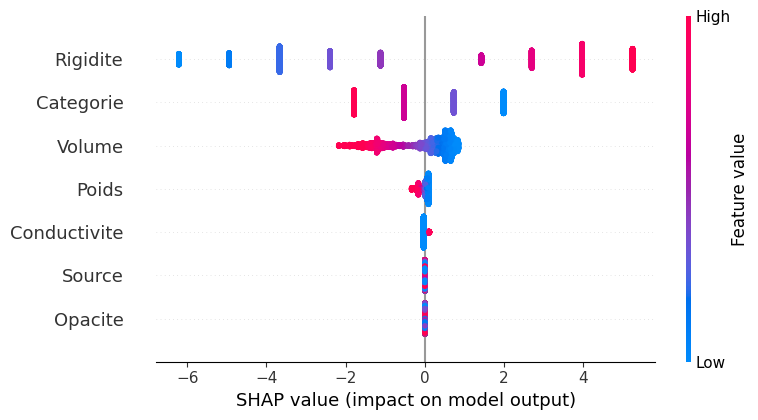

In [60]:
X_train_shap = X_train[global_top_features]
X_test_shap = X_test[global_top_features]

print("Shape X_train:", X_train_shap.shape)

shap.summary_plot(shap_values, X_train)

# optuma multimodales

In [61]:
import optuna
import numpy as np
import pandas as pd

def objective(trial, model_name):

    if model_name == "Ridge":
        model = Ridge(
            alpha=trial.suggest_float("alpha", 0.01, 10)
        )

    elif model_name == "Lasso":
        model = Lasso(
            alpha=trial.suggest_float("alpha", 0.001, 1)
        )

    elif model_name == "ElasticNet":
        model = ElasticNet(
            alpha=trial.suggest_float("alpha", 0.01, 1),
            l1_ratio=trial.suggest_float("l1_ratio", 0.1, 0.9)
        )


   

    elif model_name == "SVR":
        model = SVR(
            C=trial.suggest_float("C", 0.1, 10),
            epsilon=trial.suggest_float("epsilon", 0.01, 1),
            kernel="rbf"
        )



    # entraînement
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return r2_score(y_test, y_pred)

In [62]:
models = [
    "Ridge",
    "Lasso",
    "ElasticNet",
    "SVR",
]

results = []

for model_name in models:

    study = optuna.create_study(direction="maximize")

    study.optimize(lambda trial: objective(trial, model_name), n_trials=30)

    results.append({
        "model": model_name,
        "best_r2": study.best_value,
        "best_params": study.best_params
    })

    print(f"{model_name} OK ✔ Best R2 = {study.best_value:.4f}")

[I 2026-05-06 18:29:50,992] A new study created in memory with name: no-name-d0bdca00-79e2-4f12-94f8-7750f513c68a
[I 2026-05-06 18:29:51,000] Trial 0 finished with value: 0.9306852740934898 and parameters: {'alpha': 7.965119497047323}. Best is trial 0 with value: 0.9306852740934898.
[I 2026-05-06 18:29:51,006] Trial 1 finished with value: 0.9318586682379599 and parameters: {'alpha': 0.3425465038344947}. Best is trial 1 with value: 0.9318586682379599.
[I 2026-05-06 18:29:51,012] Trial 2 finished with value: 0.9312701631008089 and parameters: {'alpha': 4.885655448227092}. Best is trial 1 with value: 0.9318586682379599.
[I 2026-05-06 18:29:51,017] Trial 3 finished with value: 0.9305709571526303 and parameters: {'alpha': 8.501086989223113}. Best is trial 1 with value: 0.9318586682379599.
[I 2026-05-06 18:29:51,023] Trial 4 finished with value: 0.931867788207926 and parameters: {'alpha': 0.23559588010416121}. Best is trial 4 with value: 0.931867788207926.
[I 2026-05-06 18:29:51,029] Trial 5

Ridge OK ✔ Best R2 = 0.9319


[I 2026-05-06 18:29:51,389] Trial 23 finished with value: 0.9183040457114099 and parameters: {'alpha': 0.07140289427752462}. Best is trial 18 with value: 0.9318467886394027.
[I 2026-05-06 18:29:51,398] Trial 24 finished with value: 0.8206116173601568 and parameters: {'alpha': 0.29123384045862744}. Best is trial 18 with value: 0.9318467886394027.
[I 2026-05-06 18:29:51,408] Trial 25 finished with value: 0.8862880354911302 and parameters: {'alpha': 0.16688291505995587}. Best is trial 18 with value: 0.9318467886394027.
[I 2026-05-06 18:29:51,418] Trial 26 finished with value: 0.9192655463298143 and parameters: {'alpha': 0.06673664202416435}. Best is trial 18 with value: 0.9318467886394027.
[I 2026-05-06 18:29:51,427] Trial 27 finished with value: 0.8167702463385789 and parameters: {'alpha': 0.39635223161521305}. Best is trial 18 with value: 0.9318467886394027.
[I 2026-05-06 18:29:51,434] Trial 28 finished with value: 0.8027955199756756 and parameters: {'alpha': 0.6499234922667344}. Best i

Lasso OK ✔ Best R2 = 0.9318


[I 2026-05-06 18:29:51,630] Trial 20 finished with value: 0.7631324264716666 and parameters: {'alpha': 0.9770762031950959, 'l1_ratio': 0.7025602225656729}. Best is trial 11 with value: 0.9169860571833782.
[I 2026-05-06 18:29:51,640] Trial 21 finished with value: 0.8421698771345044 and parameters: {'alpha': 0.20147466275336678, 'l1_ratio': 0.5557694818856862}. Best is trial 11 with value: 0.9169860571833782.
[I 2026-05-06 18:29:51,652] Trial 22 finished with value: 0.9098342307214585 and parameters: {'alpha': 0.013187279340953963, 'l1_ratio': 0.20081429396690564}. Best is trial 11 with value: 0.9169860571833782.
[I 2026-05-06 18:29:51,664] Trial 23 finished with value: 0.8894176299318757 and parameters: {'alpha': 0.026852640770416943, 'l1_ratio': 0.15258774087728694}. Best is trial 11 with value: 0.9169860571833782.
[I 2026-05-06 18:29:51,677] Trial 24 finished with value: 0.8563367549611325 and parameters: {'alpha': 0.09564374417259816, 'l1_ratio': 0.2570548096968672}. Best is trial 11

ElasticNet OK ✔ Best R2 = 0.9202


[I 2026-05-06 18:29:54,732] Trial 0 finished with value: 0.9118034710746639 and parameters: {'C': 8.556501894677742, 'epsilon': 0.2550747916179088}. Best is trial 0 with value: 0.9118034710746639.
[I 2026-05-06 18:29:56,987] Trial 1 finished with value: 0.7407614551032656 and parameters: {'C': 0.14238110951536245, 'epsilon': 0.862849428448675}. Best is trial 0 with value: 0.9118034710746639.
[I 2026-05-06 18:30:00,776] Trial 2 finished with value: 0.9037572678313041 and parameters: {'C': 6.700122990743211, 'epsilon': 0.06911810971991728}. Best is trial 0 with value: 0.9118034710746639.
[I 2026-05-06 18:30:02,498] Trial 3 finished with value: 0.9040672500320499 and parameters: {'C': 6.592752782563837, 'epsilon': 0.6529807011976796}. Best is trial 0 with value: 0.9118034710746639.
[I 2026-05-06 18:30:03,683] Trial 4 finished with value: 0.8881248640707906 and parameters: {'C': 4.272299302326177, 'epsilon': 0.8079141929502113}. Best is trial 0 with value: 0.9118034710746639.
[I 2026-05-06

SVR OK ✔ Best R2 = 0.9165


In [63]:
results_df = pd.DataFrame(results).sort_values(by="best_r2", ascending=False)

print("\n=== COMPARAISON MODELS ===")
print(results_df)


=== COMPARAISON MODELS ===
        model   best_r2                                        best_params
0       Ridge  0.931885                    {'alpha': 0.024847023198369705}
1       Lasso  0.931847                   {'alpha': 0.0010603078615454553}
2  ElasticNet  0.920212  {'alpha': 0.01163819967540013, 'l1_ratio': 0.5...
3         SVR  0.916501  {'C': 9.992503847954357, 'epsilon': 0.36906687...


### GRAPHIQUE RÉELS vs PRÉDITS

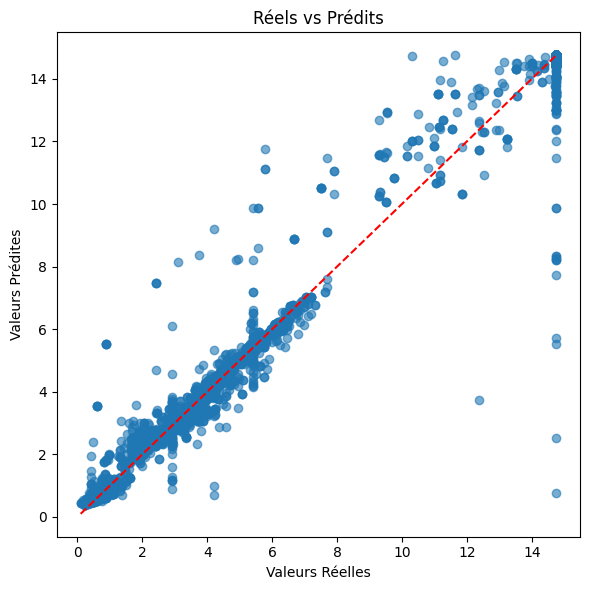

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.6)

# ligne parfaite (y = x)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')

plt.xlabel("Valeurs Réelles")
plt.ylabel("Valeurs Prédites")
plt.title("Réels vs Prédits")

plt.tight_layout()
plt.show()